# LaDe-P Demand Forecasting — XGBoost Model

## Goal
Train and evaluate an XGBoost regression model to predict `demand_count` for each `(city, region_id, aoi_id, bucket_hour)` using lag and rolling features.

## Assumptions
- `model_df` is already loaded (from the preprocessing notebook output `lade_hourly_features.csv`).
- All lag/rolling features are pre-computed and NaN rows have been dropped.
- `bucket_hour` is a datetime column.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Install xgboost if needed (Colab usually has it, but just in case)
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "xgboost", "-q"])
    import xgboost as xgb
    print("XGBoost installed, version:", xgb.__version__)

SEED = 42
np.random.seed(SEED)
print("Ready.")

XGBoost installed, version: 3.2.0
Ready.


## Step 1 — Load the Preprocessed Dataset

If `model_df` is already in memory (you ran the preprocessing notebook in the same session), skip the CSV read.
Otherwise it reads `lade_hourly_features.csv` from disk.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CSV_PATH = "/content/drive/MyDrive/lade_hourly_features.csv"

if 'model_df' not in globals():
    print("Loading from CSV...")
    model_df = pd.read_csv(CSV_PATH, parse_dates=["bucket_hour"])
    print("Loaded shape:", model_df.shape)
else:
    print("Using existing model_df from memory, shape:", model_df.shape)
    model_df["bucket_hour"] = pd.to_datetime(model_df["bucket_hour"])

model_df.head()

Loading from CSV...
Loaded shape: (609600, 18)


,city,region_id,aoi_id,aoi_type,bucket_hour,hour,dow,month,is_weekend_fri_sat,is_weekend_sat_sun,demand_count,lag_1,lag_2,lag_24,lag_48,lag_168,roll_24_mean,roll_168_mean
0,Chongqing,95,7811,1,2022-06-08 06:00:00,6,2,6,0,0,0,0.0,0.0,0.0,0.0,0.0,2.416667,2.250000
1,Chongqing,95,7811,1,2022-06-08 07:00:00,7,2,6,0,0,17,0.0,0.0,18.0,22.0,7.0,2.416667,2.250000
2,Chongqing,95,7811,1,2022-06-08 08:00:00,8,2,6,0,0,22,17.0,0.0,19.0,24.0,14.0,2.375000,2.309524
3,Chongqing,95,7811,1,2022-06-08 09:00:00,9,2,6,0,0,7,22.0,17.0,6.0,8.0,6.0,2.500000,2.357143
4,Chongqing,95,7811,1,2022-06-08 10:00:00,10,2,6,0,0,1,7.0,22.0,3.0,2.0,2.0,2.541667,2.363095


## Step 2a — Time and Spatial Features

- **Circadian**: `hour_sin`, `hour_cos` from hour of day.
- **Saudi calendar proxy**: `is_ramadan`, `is_holiday` (Ramadan windows + Saudi National Day 23 Sept).
- **Spatial**: `neighbor_lag_24_mean` = mean of `lag_24` over other AOIs in the same (city, region) for that hour.
- **AOI size**: use `aoi_area` if present in the CSV.

In [ ]:
# --- Circadian: sin/cos of hour ---
model_df["hour"] = model_df["bucket_hour"].dt.hour
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# --- Saudi calendar proxy: Ramadan (approximate Gregorian windows) ---
# Ramadan start (approx) per year: 2023 Mar 23, 2024 Mar 11, 2025 Mar 1, 2026 Feb 18
def get_ramadan_start(year):
    # Approximate: Ramadan moves ~11 days earlier each Gregorian year
    starts = {2022: np.datetime64("2022-04-02"), 2023: np.datetime64("2023-03-23"),
              2024: np.datetime64("2024-03-11"), 2025: np.datetime64("2025-03-01"),
              2026: np.datetime64("2026-02-18"), 2027: np.datetime64("2027-02-08")}
    return starts.get(year, np.datetime64(f"{year}-03-15"))  # fallback mid-March

def is_ramadan(dt):
    if pd.isna(dt): return False
    t = pd.Timestamp(dt)
    start = get_ramadan_start(t.year)
    end = start + np.timedelta64(29, "D")  # ~29 days
    return start <= np.datetime64(t.date()) <= end

model_df["is_ramadan"] = model_df["bucket_hour"].apply(is_ramadan).astype(int)

# --- Saudi holiday proxy: National Day (Sept 23) + Eid al-Fitr (1st of Shawwal, ~end of Ramadan) ---
def is_holiday(dt):
    if pd.isna(dt): return False
    t = pd.Timestamp(dt)
    # Saudi National Day
    if t.month == 9 and t.day == 23:
        return True
    # Eid al-Fitr: first 3 days after Ramadan (approximate as 1–3 days after Ramadan end)
    start = get_ramadan_start(t.year)
    eid_start = start + np.timedelta64(29, "D")
    eid_end = eid_start + np.timedelta64(3, "D")
    d = np.datetime64(t.date())
    if eid_start <= d <= eid_end:
        return True
    return False

model_df["is_holiday"] = model_df["bucket_hour"].apply(is_holiday).astype(int)

# --- Spatial: neighbor_lag_24_mean (same city, region, bucket_hour; exclude self) ---
if "lag_24" in model_df.columns:
    g = model_df.groupby(["city", "region_id", "bucket_hour"], dropna=False)
    total = g["lag_24"].transform("sum")
    cnt = g["lag_24"].transform("count")
    self_lag = model_df["lag_24"]
    # mean of others = (sum - self) / (count - 1); if count==1 use 0
    neighbor_mean = (total - self_lag) / (cnt - 1).replace(0, np.nan)
    model_df["neighbor_lag_24_mean"] = neighbor_mean.fillna(0)
else:
    model_df["neighbor_lag_24_mean"] = 0

# --- AOI area/size if available ---
if "aoi_area" not in model_df.columns and "aoi_size" in model_df.columns:
    model_df["aoi_area"] = model_df["aoi_size"]
elif "aoi_area" not in model_df.columns:
    model_df["aoi_area"] = 1.0  # placeholder when not available

print("Time/spatial features added. New columns:", [c for c in ["hour_sin","hour_cos","is_ramadan","is_holiday","neighbor_lag_24_mean","aoi_area"] if c in model_df.columns])

Time/spatial features added. New columns: ['hour_sin', 'hour_cos', 'is_ramadan', 'is_holiday', 'neighbor_lag_24_mean', 'aoi_area']


## Step 2 — Chronological Train / Val / Test Split

We split **globally** by time (not per AOI), so:
- **Train**: first 60% of hours
- **Val**: next 20% of hours
- **Test**: last 20% of hours

This prevents any future data from leaking into training.

In [ ]:
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20

all_hours = model_df["bucket_hour"].sort_values().unique()
n_hours   = len(all_hours)

train_end = all_hours[int(n_hours * TRAIN_RATIO) - 1]
val_end   = all_hours[int(n_hours * (TRAIN_RATIO + VAL_RATIO)) - 1]

def assign_split(bh):
    if bh <= train_end:
        return "train"
    elif bh <= val_end:
        return "val"
    else:
        return "test"

model_df["split"] = model_df["bucket_hour"].map(assign_split)

split_counts = model_df["split"].value_counts().sort_index()
print(split_counts)
print(f"\nTrain ends:  {train_end}")
print(f"Val ends:    {val_end}")
print(f"Test starts: {model_df.loc[model_df['split']=='test','bucket_hour'].min()}")

split
test     122100
train    365700
val      121800
Name: count, dtype: int64

Train ends:  2022-07-29 00:00:00
Val ends:    2022-08-14 22:00:00
Test starts: 2022-08-14 23:00:00


## Step 3 — Feature Engineering

- **Drop** `bucket_hour` as a direct feature (time info is captured by `hour`, `dow`, `month`).
- **One-hot encode** `city` and `aoi_type` (high-cardinality `aoi_id` and `region_id` are kept as numeric IDs).

In [ ]:
TARGET = "demand_count"

# Columns to drop (not used as features)
DROP_COLS = ["bucket_hour", "split", TARGET]

# One-hot encode low-cardinality categoricals
OHE_COLS = ["city", "aoi_type"]

encoded = pd.get_dummies(model_df.drop(columns=DROP_COLS), columns=OHE_COLS, drop_first=True)

FEATURE_COLS = encoded.columns.tolist()
print(f"Number of features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Number of features: 31
['region_id', 'aoi_id', 'hour', 'dow', 'month', 'is_weekend_fri_sat', 'is_weekend_sat_sun', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168', 'roll_24_mean', 'roll_168_mean', 'hour_sin', 'hour_cos', 'is_ramadan', 'is_holiday', 'neighbor_lag_24_mean', 'aoi_area', 'aoi_type_1', 'aoi_type_3', 'aoi_type_4', 'aoi_type_5', 'aoi_type_6', 'aoi_type_7', 'aoi_type_8', 'aoi_type_10', 'aoi_type_12', 'aoi_type_13', 'aoi_type_14']


## Step 4 — Prepare Train / Val / Test Arrays

- **Train**: sample up to 2M rows (to keep RAM manageable).
- **Val / Test**: use full split if memory allows, otherwise sample similarly.
- **sample_weight**: per-row weight = (number of train observations for that AOI), normalized to mean 1, to upweight AOIs with more data.

In [ ]:
MAX_TRAIN_ROWS = 2_000_000

split_mask = model_df["split"]

train_idx = model_df.index[split_mask == "train"]
val_idx   = model_df.index[split_mask == "val"]
test_idx  = model_df.index[split_mask == "test"]

# Sample train rows if too large
if len(train_idx) > MAX_TRAIN_ROWS:
    train_idx = train_idx[np.random.RandomState(SEED).choice(
        len(train_idx), MAX_TRAIN_ROWS, replace=False
    )]
    print(f"Train sampled to {MAX_TRAIN_ROWS:,} rows")
else:
    print(f"Train rows: {len(train_idx):,}")

X_train = encoded.loc[train_idx]
y_train = model_df.loc[train_idx, TARGET]

X_val   = encoded.loc[val_idx]
y_val   = model_df.loc[val_idx, TARGET]

X_test  = encoded.loc[test_idx]
y_test  = model_df.loc[test_idx, TARGET]

# Sample weights: upweight AOIs with more data (helps sparse AOIs get learned)
train_meta = model_df.loc[train_idx, ["city", "region_id", "aoi_id"]].copy()
aoi_counts = model_df.loc[train_idx].groupby(["city", "region_id", "aoi_id"]).size().reset_index(name="n_obs")
train_meta = train_meta.merge(aoi_counts, on=["city", "region_id", "aoi_id"], how="left")
sample_weight = train_meta["n_obs"].fillna(1).values.astype(np.float64)
sample_weight = sample_weight / sample_weight.mean()  # normalize so mean weight = 1

print(f"Val rows:  {len(X_val):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Sample weight range: [{sample_weight.min():.3f}, {sample_weight.max():.3f}]")

Train rows: 365,700
Val rows:  121,800
Test rows: 122,100
Sample weight range: [1.000, 1.000]


## Step 5 — Baseline Models

Two simple baselines:
- **Baseline A** (`lag_24`): predict using the value from 24 hours ago.
- **Baseline B** (`roll_24_mean`): predict using the 24-hour rolling average.

In [ ]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    # Avoid division by zero (when both actual and forecast are zero)
    mask = denom > 0
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def evaluate(y_true, y_pred, name, split_name):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return {
        "Model": name,
        "Split": split_name,
        "MAE":   round(mae(y_true, y_pred), 4),
        "RMSE":  round(rmse(y_true, y_pred), 4),
        "sMAPE": round(smape(y_true, y_pred), 2),
    }

results = []

for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_test, y_test)]:
    results.append(evaluate(y_s, X_s["lag_24"],       "Baseline lag_24",      split_name))
    results.append(evaluate(y_s, X_s["roll_24_mean"], "Baseline roll_24_mean", split_name))

print(pd.DataFrame(results))

                   Model Split     MAE    RMSE   sMAPE
0        Baseline lag_24   val  0.3579  0.8710  131.85
1  Baseline roll_24_mean   val  0.5912  1.0219  182.29
2        Baseline lag_24  test  0.3089  0.8020  135.58
3  Baseline roll_24_mean  test  0.4908  0.9039  184.20


## Step 6b — (Optional) Zero-inflated model & reg:squaredlogerror

- **Zero-inflated**: Logistic regression for P(demand > 0), then XGBoost for conditional mean E[demand | demand > 0]; final prediction = P(demand>0) × conditional mean.
- **reg:squaredlogerror**: XGBoost objective that penalizes small values less (good for sparse demand).

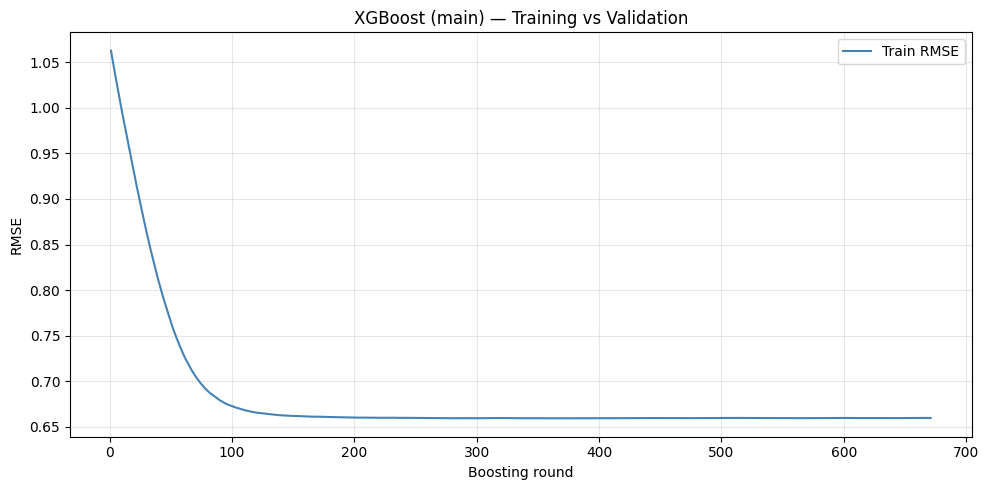

In [ ]:
def plot_train_val_curves(evals_result, title="Model", metric="rmse"):
    fig, ax = plt.subplots(figsize=(10, 5))

    if "validation_0" in evals_result:
        train_metric = evals_result["validation_0"][metric]
        rounds = range(1, len(train_metric) + 1)
        ax.plot(rounds, train_metric, label=f"Train {metric.upper()}",
                color="steelblue", linewidth=1.5)

    if "validation_1" in evals_result:
        val_metric = evals_result["validation_1"][metric]
        rounds = range(1, len(val_metric) + 1)
        ax.plot(rounds, val_metric, label=f"Val {metric.upper()}",
                color="tomato", linewidth=1.5)

    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{title} — Training vs Validation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_train_val_curves(model.evals_result(),   title="XGBoost (main)")
# If you have these:
# plot_train_val_curves(xgb_cond.evals_result(), title="XGBoost (zero-inflated, conditional)")
# plot_train_val_curves(xgb_sle.evals_result(),  title="XGBoost (squaredlogerror)")

In [ ]:
from sklearn.linear_model import LogisticRegression

try:
    import subprocess
    gpu_check = subprocess.run(["nvidia-smi"], capture_output=True)
    _tree_method = "hist" if gpu_check.returncode == 0 else "hist"
except Exception:
    _tree_method = "hist"

# --- 1) Zero-inflated: P(demand > 0) with logistic, E[demand|>0] with XGBoost ---
y_train_binary = (y_train > 0).astype(int)
logit = LogisticRegression(max_iter=500, random_state=SEED, C=0.5)
logit.fit(X_train, y_train_binary)

# Train XGBoost on positive-demand rows only (conditional mean)
pos_mask = y_train > 0
X_train_pos = X_train.loc[pos_mask]
y_train_pos = y_train.loc[pos_mask]
w_pos = sample_weight[pos_mask]

xgb_cond = xgb.XGBRegressor(
    objective="reg:squarederror", tree_method=_tree_method,
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1,
    early_stopping_rounds=25, eval_metric="rmse",
)
xgb_cond.fit(
    X_train_pos, y_train_pos, sample_weight=w_pos,
    eval_set=[(X_train_pos, y_train_pos), (X_val, y_val)],
    verbose=False,
)

# Predict: P(demand>0) * E[demand|>0]
p_val = logit.predict_proba(X_val)[:, 1]
p_test = logit.predict_proba(X_test)[:, 1]
cond_val = np.clip(xgb_cond.predict(X_val), 0, None)
cond_test = np.clip(xgb_cond.predict(X_test), 0, None)
val_preds_zi = p_val * cond_val
test_preds_zi = p_test * cond_test

results.append(evaluate(y_val,  val_preds_zi,  "XGBoost (zero-inflated)", "val"))
results.append(evaluate(y_test, test_preds_zi, "XGBoost (zero-inflated)", "test"))
print("Zero-inflated model evaluated.")

# --- 2) XGBoost with reg:squaredlogerror (penalizes small values less) ---
xgb_sle = xgb.XGBRegressor(
    objective="reg:squaredlogerror", tree_method=_tree_method,
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1,
    early_stopping_rounds=30, eval_metric="rmse",
)
# squaredlogerror expects nonnegative target; log1p(0)=0
xgb_sle.fit(
    X_train, y_train, sample_weight=sample_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)
val_preds_sle = np.clip(xgb_sle.predict(X_val), 0, None)
test_preds_sle = np.clip(xgb_sle.predict(X_test), 0, None)
results.append(evaluate(y_val,  val_preds_sle,  "XGBoost (squaredlogerror)", "val"))
results.append(evaluate(y_test, test_preds_sle, "XGBoost (squaredlogerror)", "test"))
print("reg:squaredlogerror model evaluated.")

Zero-inflated model evaluated.
[0]	validation_0-rmse:1.26742	validation_1-rmse:1.06272
[50]	validation_0-rmse:0.90323	validation_1-rmse:0.76430
[100]	validation_0-rmse:0.76425	validation_1-rmse:0.67399
[150]	validation_0-rmse:0.74200	validation_1-rmse:0.66359
[200]	validation_0-rmse:0.73648	validation_1-rmse:0.66107
[250]	validation_0-rmse:0.73373	validation_1-rmse:0.66067
[300]	validation_0-rmse:0.73163	validation_1-rmse:0.66060
[304]	validation_0-rmse:0.73144	validation_1-rmse:0.66055
reg:squaredlogerror model evaluated.


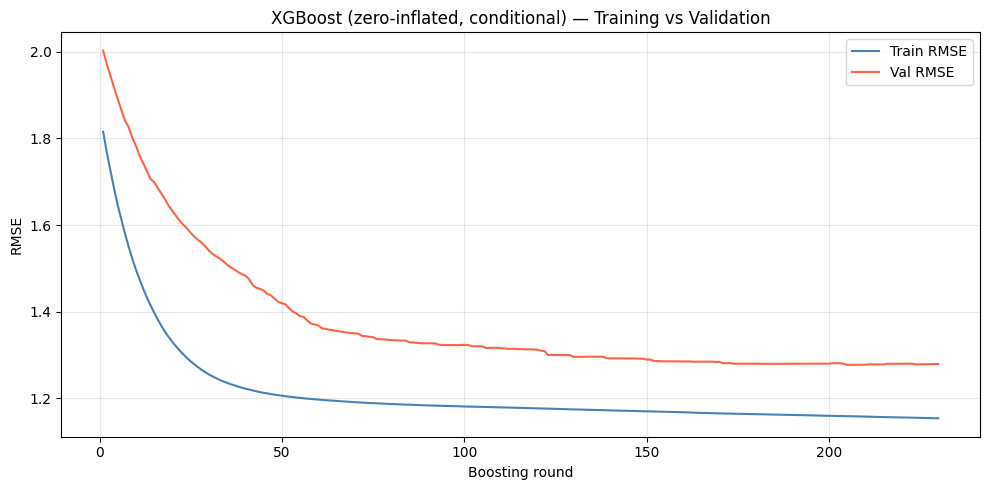

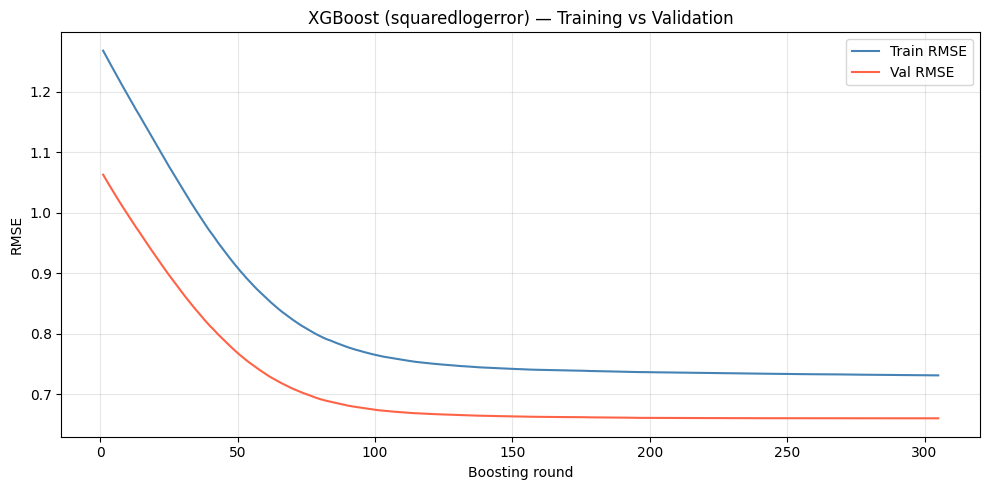

In [ ]:
plot_train_val_curves(xgb_cond.evals_result(), title="XGBoost (zero-inflated, conditional)")
plot_train_val_curves(xgb_sle.evals_result(),  title="XGBoost (squaredlogerror)")

## Step 6 — Train XGBoost with Early Stopping

In [ ]:
# Use gpu_hist if a GPU is available, otherwise fall back to hist
try:
    import subprocess
    gpu_check = subprocess.run(["nvidia-smi"], capture_output=True)
    tree_method = "hist" if gpu_check.returncode == 0 else "hist"
except Exception:
    tree_method = "hist"

print(f"Using tree_method='{tree_method}'")

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",            # switch to "gpu_hist" if you truly have GPU build
    n_estimators=5000,             # high cap; early stopping will pick best
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,           # a bit more conservative for sparse/zero-heavy
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric=["rmse", "mae"],
    early_stopping_rounds=100,     # patience helps with many features/lags
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

Using tree_method='hist'
[0]	validation_0-rmse:1.20400	validation_0-mae:0.70821	validation_1-rmse:1.02124	validation_1-mae:0.64980
[50]	validation_0-rmse:0.71510	validation_0-mae:0.35393	validation_1-rmse:0.64782	validation_1-mae:0.32535
[100]	validation_0-rmse:0.70120	validation_0-mae:0.33273	validation_1-rmse:0.64347	validation_1-mae:0.30533
[150]	validation_0-rmse:0.69599	validation_0-mae:0.33006	validation_1-rmse:0.64329	validation_1-mae:0.30358
[200]	validation_0-rmse:0.69122	validation_0-mae:0.32894	validation_1-rmse:0.64351	validation_1-mae:0.30352
[250]	validation_0-rmse:0.68695	validation_0-mae:0.32785	validation_1-rmse:0.64385	validation_1-mae:0.30355
[300]	validation_0-rmse:0.68252	validation_0-mae:0.32671	validation_1-rmse:0.64412	validation_1-mae:0.30357
[311]	validation_0-rmse:0.68152	validation_0-mae:0.32642	validation_1-rmse:0.64415	validation_1-mae:0.30353

Best iteration: 211


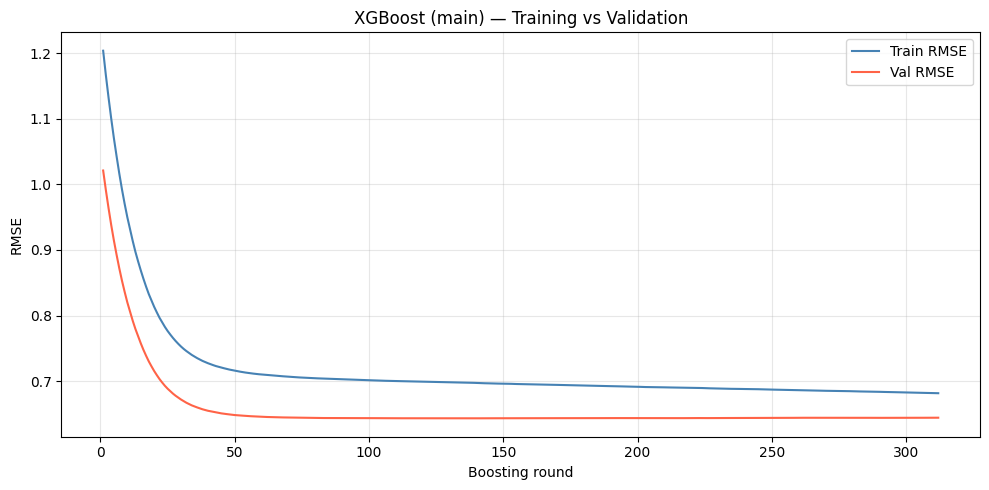

In [ ]:
def plot_train_val_curves(evals_result, title="Model", metric="rmse"):
    fig, ax = plt.subplots(figsize=(10, 5))

    if "validation_0" in evals_result:
        train_metric = evals_result["validation_0"][metric]
        rounds = range(1, len(train_metric) + 1)
        ax.plot(rounds, train_metric, label=f"Train {metric.upper()}",
                color="steelblue", linewidth=1.5)

    if "validation_1" in evals_result:
        val_metric = evals_result["validation_1"][metric]
        rounds = range(1, len(val_metric) + 1)
        ax.plot(rounds, val_metric, label=f"Val {metric.upper()}",
                color="tomato", linewidth=1.5)

    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{title} — Training vs Validation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_train_val_curves(model.evals_result(),   title="XGBoost (main)")
# If you have these:
# plot_train_val_curves(xgb_cond.evals_result(), title="XGBoost (zero-inflated, conditional)")
# plot_train_val_curves(xgb_sle.evals_result(),  title="XGBoost (squaredlogerror)")

## Step 7 — Evaluate XGBoost on Val and Test

In [ ]:
val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

# Clip negatives — demand cannot be < 0
val_preds  = np.clip(val_preds,  0, None)
test_preds = np.clip(test_preds, 0, None)

results.append(evaluate(y_val,  val_preds,  "XGBoost", "val"))
results.append(evaluate(y_test, test_preds, "XGBoost", "test"))

# Pivot into a clean comparison table
results_df = pd.DataFrame(results)
comparison = results_df.pivot(index="Model", columns="Split", values=["MAE", "RMSE", "sMAPE"])
comparison.columns = [f"{metric}_{split}" for metric, split in comparison.columns]
comparison = comparison[["MAE_val", "RMSE_val", "sMAPE_val", "MAE_test", "RMSE_test", "sMAPE_test"]]

print("\n=== Model Comparison ===")
print(comparison.to_string())


=== Model Comparison ===
                           MAE_val  RMSE_val  sMAPE_val  MAE_test  RMSE_test  sMAPE_test
Model                                                                                   
Baseline lag_24             0.3579    0.8710     131.85    0.3089     0.8020      135.58
Baseline roll_24_mean       0.5912    1.0219     182.29    0.4908     0.9039      184.20
XGBoost                     0.2931    0.6595     168.94    0.2595     0.6040      172.40
XGBoost (squaredlogerror)   0.2945    0.6605     167.40    0.2612     0.6049      169.70
XGBoost (zero-inflated)     0.3099    0.6792     177.08    0.2709     0.6252      181.89


## Step 8 — Feature Importance

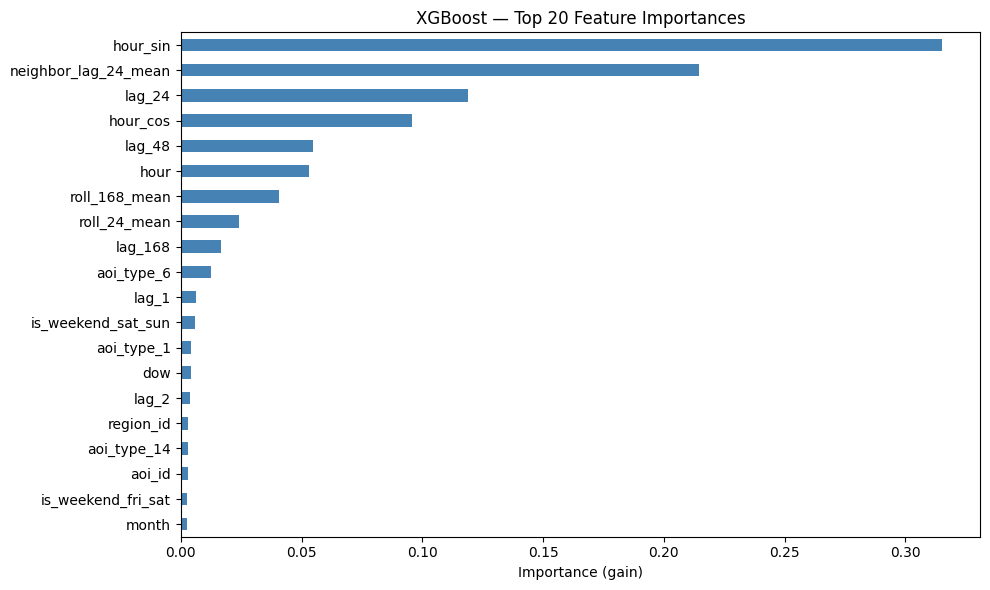

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("XGBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## Step 9 — Example AOI Plot: Actual vs Predicted

Pick the busiest AOI in the test set and plot actual demand vs XGBoost prediction vs lag_24 baseline.

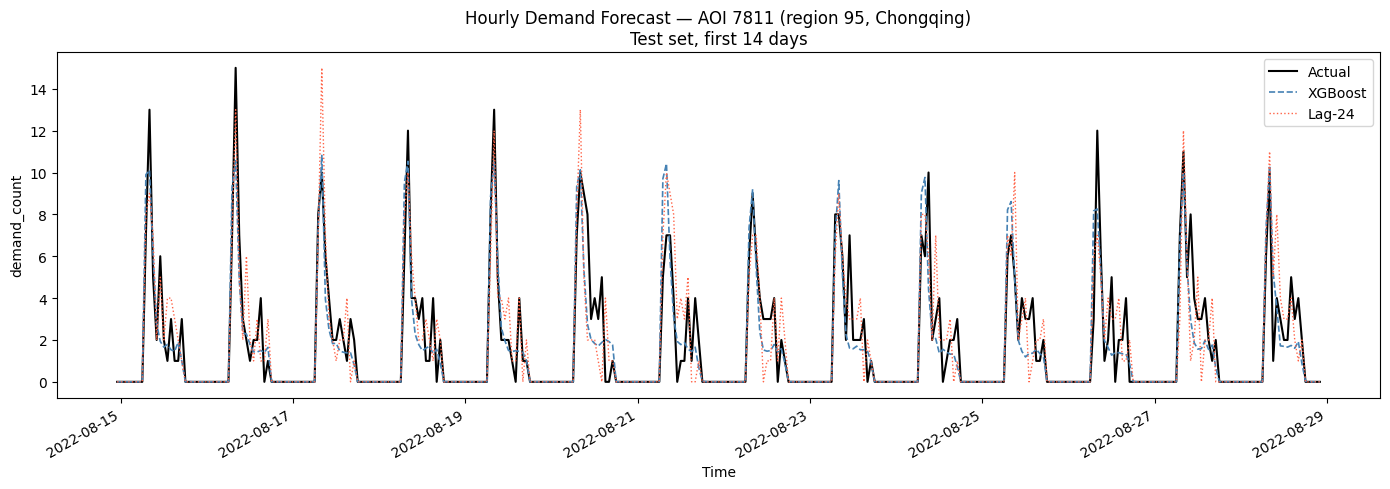


Selected AOI: city=Chongqing, region_id=95, aoi_id=7811
Test rows for this AOI: 407


In [ ]:
# Attach predictions back to the test portion of model_df
test_slice = model_df.loc[test_idx].copy()
test_slice["pred_xgb"]   = test_preds
test_slice["pred_lag24"] = X_test["lag_24"].values

# Choose the AOI with the highest total demand in test
best_aoi = (
    test_slice.groupby(["city", "region_id", "aoi_id"])["demand_count"]
    .sum()
    .idxmax()
)
city_s, region_s, aoi_s = best_aoi

aoi_test = (
    test_slice[
        (test_slice["city"] == city_s) &
        (test_slice["region_id"] == region_s) &
        (test_slice["aoi_id"] == aoi_s)
    ]
    .sort_values("bucket_hour")
)

# Limit plot to first 14 days for readability
plot_days = 14
aoi_test_plot = aoi_test.head(24 * plot_days)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["demand_count"],
        label="Actual",   color="black",      linewidth=1.5)
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_xgb"],
        label="XGBoost",  color="steelblue",  linewidth=1.2, linestyle="--")
ax.plot(aoi_test_plot["bucket_hour"], aoi_test_plot["pred_lag24"],
        label="Lag-24",   color="tomato",     linewidth=1.0, linestyle=":")

ax.set_title(f"Hourly Demand Forecast — AOI {aoi_s} (region {region_s}, {city_s})\nTest set, first {plot_days} days")
ax.set_xlabel("Time")
ax.set_ylabel("demand_count")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\nSelected AOI: city={city_s}, region_id={region_s}, aoi_id={aoi_s}")
print(f"Test rows for this AOI: {len(aoi_test)}")